# Economically Meaningful Target Evaluation

Label stays as raw future midprice change (price-process). Economic cost
enters only at the evaluation layer via a configurable taker round-trip fee
proxy. The threshold grid is in bps and is chosen to be at fee-scale, not
at noise-cleaning scale.

We test whether:
1. A compact pack of new microstructure features (OFI, queue delta, depth
   count, time since last mid move, signed trade volume, microprice realized
   vol) materially improves directional quality on bps-scale moves.
2. Any configuration yields `net_edge = mean_signed_move − fee_proxy > 0`
   on test, for realistic Binance USDT-M futures taker fee assumptions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from src.analysis.io import load_dataset_with_meta
from src.analysis.market_context import attach_segment_id
from src.analysis.baseline_eval import full_utc_days, split_by_utc_days
from src.dataset.schema import (
    OLD_FEATURE_COLUMNS, NEW_FEATURE_COLUMNS, FEATURE_COLUMNS, LABEL_COL,
)

pd.set_option("display.float_format", "{:.4f}".format)
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

/Users/efremtsevv/scripts/hft/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
DS_DIR = Path("../data/datasets/binance/BTCUSDT_v2")
DS_BASE = "dataset_v3_d4D_i100_tw1000_w600"

HORIZONS_MS = [2000, 5000, 10000]

# Threshold grid in bps — chosen at fee-scale, not noise-scale.
THRESHOLDS_BPS = [2.0, 4.0, 6.0]

# Taker round-trip fee proxy (bps). Defaults to Binance USDT-M futures VIP0
# (0.04% × 2 = 8 bps). Spot taker is ~10 bps; lower VIP tiers ~5 bps.
FEE_DEFAULT_BPS = 8.0
FEE_SWEEP_BPS = [5.0, 8.0, 10.0]

# Coverage target used to select each model's per-horizon trade threshold on
# train. Same coverage across models gives a fair comparison.
TARGET_COVERAGE = 0.05

# Reference price for bps ↔ price conversion.
# Median midprice from the v2 book replay, used only as a scalar.
REF_PRICE = 69_492.49

# Split in full UTC days. 4-day v2 recording aligns to 3 full UTC days,
# so 1/1/1 is the maximum available under this policy.
TRAIN_DAYS, VAL_DAYS, TEST_DAYS = 1, 1, 1

SIMPLE_FEATURES = ["microprice_minus_mid", "imbalance_1"]

## Load & split

Loads every horizon whose parquet file exists. Missing horizons are skipped
with a warning so the notebook still runs as datasets are being rebuilt.

In [3]:
def load_and_split(h_ms: int):
    path = DS_DIR / f"{DS_BASE}_h{h_ms}.parquet"
    if not path.exists():
        print(f"SKIP h{h_ms}: {path.name} not found")
        return None
    df, meta = load_dataset_with_meta(path)
    attach_segment_id(df, int(meta["interval_ms"]))
    h = int(meta["horizon_ms"])
    days = full_utc_days(df)
    need = TRAIN_DAYS + VAL_DAYS + TEST_DAYS
    assert len(days) >= need, f"h={h}ms: need {need} full days, have {len(days)}"
    t = days[:TRAIN_DAYS]
    v = days[TRAIN_DAYS:TRAIN_DAYS + VAL_DAYS]
    s = days[TRAIN_DAYS + VAL_DAYS:TRAIN_DAYS + VAL_DAYS + TEST_DAYS]
    print(f"h{h_ms}: train={t}  val={v}  test={s}")
    parts = split_by_utc_days(df, t, v, s, h)
    return {"parts": parts, "h": h}


data = {h: d for h in HORIZONS_MS if (d := load_and_split(h)) is not None}
available_horizons = sorted(data.keys())
print(f"\nAvailable horizons: {available_horizons}")

h2000: train=[datetime.date(2026, 3, 24)]  val=[datetime.date(2026, 3, 25)]  test=[datetime.date(2026, 3, 26)]


  Purged 20 rows from train tail
  Purged 20 rows from val tail
train:    835,117 rows  [2026-03-24 00:00:00+00:00 → 2026-03-24 23:59:57.900000+00:00]
  val:    844,999 rows  [2026-03-25 00:00:00+00:00 → 2026-03-25 23:59:57.900000+00:00]
 test:    864,000 rows  [2026-03-26 00:00:00+00:00 → 2026-03-26 23:59:59.900000+00:00]


h5000: train=[datetime.date(2026, 3, 24)]  val=[datetime.date(2026, 3, 25)]  test=[datetime.date(2026, 3, 26)]


  Purged 50 rows from train tail
  Purged 50 rows from val tail
train:    834,997 rows  [2026-03-24 00:00:00+00:00 → 2026-03-24 23:59:54.900000+00:00]
  val:    844,879 rows  [2026-03-25 00:00:00+00:00 → 2026-03-25 23:59:54.900000+00:00]
 test:    864,000 rows  [2026-03-26 00:00:00+00:00 → 2026-03-26 23:59:59.900000+00:00]


h10000: train=[datetime.date(2026, 3, 24)]  val=[datetime.date(2026, 3, 25)]  test=[datetime.date(2026, 3, 26)]


  Purged 100 rows from train tail
  Purged 100 rows from val tail
train:    834,797 rows  [2026-03-24 00:00:00+00:00 → 2026-03-24 23:59:49.900000+00:00]
  val:    844,679 rows  [2026-03-25 00:00:00+00:00 → 2026-03-25 23:59:49.900000+00:00]
 test:    864,000 rows  [2026-03-26 00:00:00+00:00 → 2026-03-26 23:59:59.900000+00:00]

Available horizons: [2000, 5000, 10000]


## Target construction

Label is raw `future_mid − current_mid` in price. We convert to bps using
`REF_PRICE` and define a 3-class target per threshold `τ` in bps:
- `+1` if `label_bps >= τ`
- `-1` if `label_bps <= -τ`
- `0` otherwise

In [4]:
def label_to_bps(label: np.ndarray) -> np.ndarray:
    return label / REF_PRICE * 1e4


def make_class_target(label_bps: np.ndarray, thr_bps: float) -> np.ndarray:
    return np.where(label_bps >= thr_bps, 1,
            np.where(label_bps <= -thr_bps, -1, 0))

## Class balance vs threshold (train)

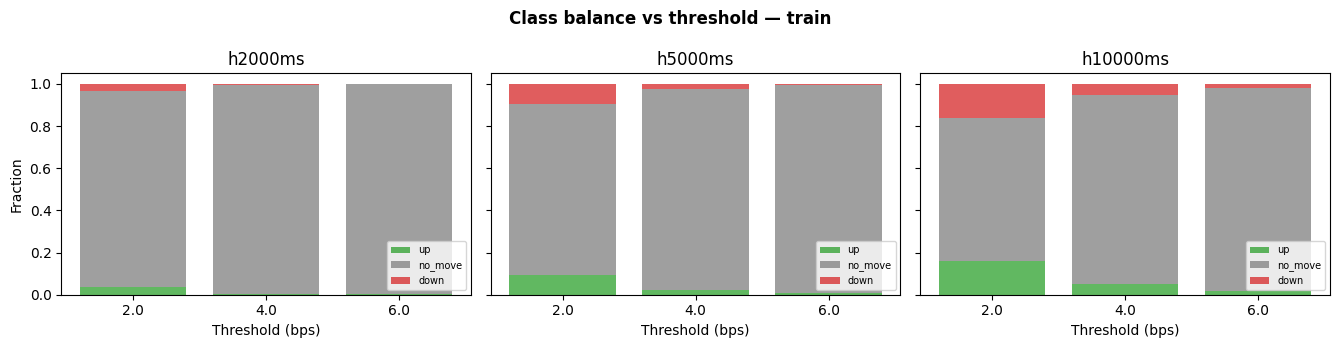

In [5]:
n_h = len(available_horizons)
if n_h > 0:
    fig, axes = plt.subplots(1, n_h, figsize=(4.5 * n_h, 3.5), sharey=True, squeeze=False)
    axes = axes[0]
    x_pos = np.arange(len(THRESHOLDS_BPS))
    for ax, h_ms in zip(axes, available_horizons):
        label_bps = label_to_bps(data[h_ms]["parts"]["train"][LABEL_COL].values)
        up, flat, dn = [], [], []
        for b in THRESHOLDS_BPS:
            ct = make_class_target(label_bps, b)
            up.append((ct == 1).mean())
            flat.append((ct == 0).mean())
            dn.append((ct == -1).mean())
        ax.bar(x_pos, up, label="up", alpha=0.75, color="tab:green")
        ax.bar(x_pos, flat, bottom=up, label="no_move", alpha=0.75, color="tab:gray")
        ax.bar(x_pos, dn, bottom=np.array(up) + np.array(flat),
               label="down", alpha=0.75, color="tab:red")
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"{b:.1f}" for b in THRESHOLDS_BPS])
        ax.set_xlabel("Threshold (bps)")
        ax.set_title(f"h{h_ms}ms")
        ax.legend(fontsize=7)
    axes[0].set_ylabel("Fraction")
    fig.suptitle("Class balance vs threshold — train", fontweight="bold")
    fig.tight_layout()
    plt.show()

## Baselines and trade generation rule

Five scorers:
- `microprice_minus_mid` — raw feature as score
- `imbalance_1` — raw feature as score
- `Ridge(old)` — old 8 features
- `Ridge(new)` — new 8 features (ablation: signal from new pack alone)
- `Ridge(old+new)` — full set

Trade rule: `|score| > score_thr`, where `score_thr` is chosen on train as
the `(1 − TARGET_COVERAGE)` quantile of `|score|`. This equalises per-model
coverage so precision/edge are comparable.

In [6]:
class SimpleFeatureModel:
    def __init__(self, feature: str):
        self.feature = feature
        self.name = feature
    def fit(self, X, y): return self
    def predict(self, X): return X[self.feature].values.astype(float)


class RidgeModel:
    def __init__(self, features: list[str], name: str, alpha: float = 1.0):
        self.features = features
        self.name = name
        self.scaler = StandardScaler()
        self.model = Ridge(alpha=alpha)
    def fit(self, X, y):
        Xs = self.scaler.fit_transform(X[self.features])
        self.model.fit(Xs, y)
        return self
    def predict(self, X):
        return self.model.predict(self.scaler.transform(X[self.features]))


def make_models() -> list:
    return [
        SimpleFeatureModel("microprice_minus_mid"),
        SimpleFeatureModel("imbalance_1"),
        RidgeModel(OLD_FEATURE_COLUMNS,       name="Ridge(old)"),
        RidgeModel(NEW_FEATURE_COLUMNS,       name="Ridge(new)"),
        RidgeModel(FEATURE_COLUMNS,           name="Ridge(old+new)"),
    ]


def score_threshold_for_coverage(abs_score: np.ndarray, cov: float) -> float:
    return float(np.quantile(abs_score, 1.0 - cov))

## Evaluation helper

For each `(horizon, threshold_bps, model)`:
- Fit on train, choose `score_thr` from train |score| at target coverage.
- On eval split, generate trades where `|score| > score_thr`.
- Measure coverage, precision long / short, mean signed move bps,
  and `net_edge_bps = mean_signed_move_bps − fee`.

In [7]:
def eval_candidate(model, train, eval_split, thr_bps, fee_bps):
    model.fit(train, train[LABEL_COL].values)
    train_score = model.predict(train)
    score_thr = score_threshold_for_coverage(np.abs(train_score), TARGET_COVERAGE)

    score = model.predict(eval_split)
    label = eval_split[LABEL_COL].values
    label_bps = label_to_bps(label)
    y_class = make_class_target(label_bps, thr_bps)

    trade_mask = np.abs(score) > score_thr
    pred = np.sign(score)
    long_mask = trade_mask & (pred > 0)
    short_mask = trade_mask & (pred < 0)

    def _safe(m, v):
        return float(v[m].mean()) if m.any() else np.nan

    long_precision = _safe(long_mask, (y_class == 1).astype(float))
    short_precision = _safe(short_mask, (y_class == -1).astype(float))
    long_mean_bps = _safe(long_mask, label_bps)
    short_mean_bps = _safe(short_mask, -label_bps)
    signed_edge_bps = np.where(long_mask, label_bps,
                      np.where(short_mask, -label_bps, 0.0))
    mean_signed_bps = float(signed_edge_bps[trade_mask].mean()) if trade_mask.any() else np.nan
    median_signed_bps = float(np.median(signed_edge_bps[trade_mask])) if trade_mask.any() else np.nan

    return {
        "score_thr": score_thr,
        "coverage": float(trade_mask.mean()),
        "long_n": int(long_mask.sum()),
        "short_n": int(short_mask.sum()),
        "long_precision": long_precision,
        "short_precision": short_precision,
        "long_mean_bps": long_mean_bps,
        "short_mean_bps": short_mean_bps,
        "mean_signed_bps": mean_signed_bps,
        "median_signed_bps": median_signed_bps,
        "net_edge_bps": mean_signed_bps - fee_bps if not np.isnan(mean_signed_bps) else np.nan,
    }

## Val evaluation over all combinations

In [8]:
val_rows = []
trained_models = {}  # (h_ms, model_name) -> fitted model (reused for test)

for h_ms in available_horizons:
    parts = data[h_ms]["parts"]
    for model in make_models():
        # Fit once per model per horizon; reuse across thresholds.
        model.fit(parts["train"], parts["train"][LABEL_COL].values)
        trained_models[(h_ms, model.name)] = model
        # Score once, reuse for each threshold.
        train_score = model.predict(parts["train"])
        score_thr = score_threshold_for_coverage(np.abs(train_score), TARGET_COVERAGE)
        val_score = model.predict(parts["val"])
        val_label = parts["val"][LABEL_COL].values
        val_label_bps = label_to_bps(val_label)
        trade_mask = np.abs(val_score) > score_thr
        pred_sign = np.sign(val_score)
        long_mask = trade_mask & (pred_sign > 0)
        short_mask = trade_mask & (pred_sign < 0)
        signed_edge_bps = np.where(long_mask, val_label_bps,
                           np.where(short_mask, -val_label_bps, 0.0))
        mean_signed = float(signed_edge_bps[trade_mask].mean()) if trade_mask.any() else np.nan
        for thr_bps in THRESHOLDS_BPS:
            y_class = make_class_target(val_label_bps, thr_bps)
            lp = float((y_class == 1)[long_mask].mean()) if long_mask.any() else np.nan
            sp = float((y_class == -1)[short_mask].mean()) if short_mask.any() else np.nan
            val_rows.append({
                "horizon": h_ms,
                "threshold_bps": thr_bps,
                "model": model.name,
                "coverage": float(trade_mask.mean()),
                "long_n": int(long_mask.sum()),
                "short_n": int(short_mask.sum()),
                "long_precision": lp,
                "short_precision": sp,
                "mean_signed_bps": mean_signed,
                "net_edge_default": mean_signed - FEE_DEFAULT_BPS if not np.isnan(mean_signed) else np.nan,
            })
val_df = pd.DataFrame(val_rows)
val_df.head(10)

,horizon,threshold_bps,model,coverage,long_n,short_n,long_precision,short_precision,mean_signed_bps,net_edge_default
0,2000,2.0000,microprice_minus_mid,0.0350,15384,14191,0.1316,0.1416,0.9057,-7.0943
1,2000,4.0000,microprice_minus_mid,0.0350,15384,14191,0.0330,0.0240,0.9057,-7.0943
2,2000,6.0000,microprice_minus_mid,0.0350,15384,14191,0.0110,0.0066,0.9057,-7.0943
3,2000,2.0000,imbalance_1,0.0349,15366,14133,0.1285,0.1385,0.9001,-7.0999
4,2000,4.0000,imbalance_1,0.0349,15366,14133,0.0318,0.0224,0.9001,-7.0999
5,2000,6.0000,imbalance_1,0.0349,15366,14133,0.0104,0.0055,0.9001,-7.0999
6,2000,2.0000,Ridge(old),0.0385,19721,12833,0.1308,0.1404,0.8317,-7.1683
7,2000,4.0000,Ridge(old),0.0385,19721,12833,0.0337,0.0316,0.8317,-7.1683
8,2000,6.0000,Ridge(old),0.0385,19721,12833,0.0129,0.0110,0.8317,-7.1683
9,2000,2.0000,Ridge(new),0.0244,10248,10372,0.1113,0.1116,0.6612,-7.3388


### Mean signed move (val)

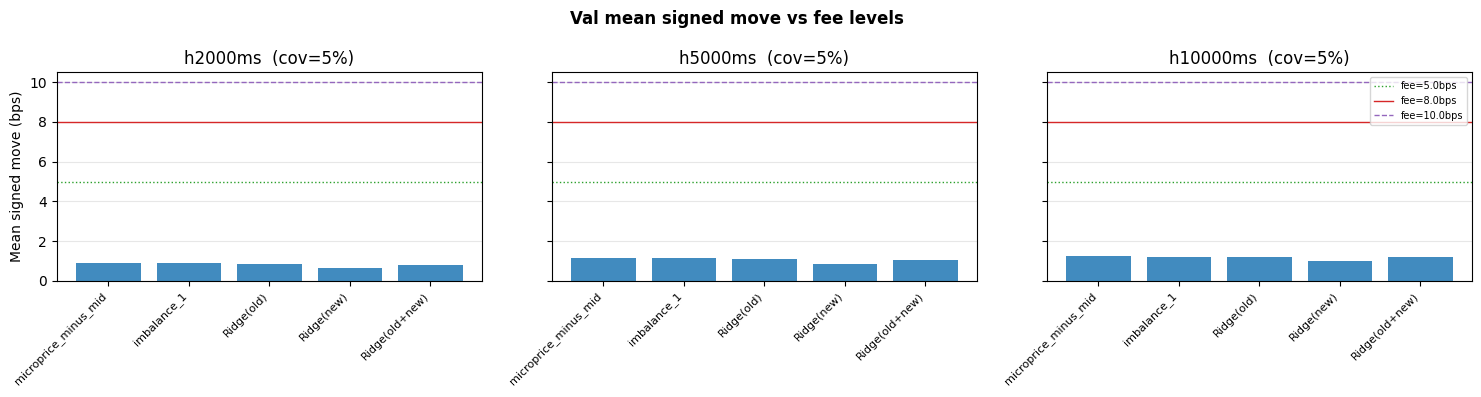

In [9]:
# Mean signed move does not depend on threshold — but threshold affects
# precision. We plot mean signed move per (horizon, model) as bars, and
# overlay fee levels as horizontal lines.
n_h = len(available_horizons)
if n_h > 0:
    fig, axes = plt.subplots(1, n_h, figsize=(5 * n_h, 4), sharey=True, squeeze=False)
    axes = axes[0]
    model_order = [m.name for m in make_models()]
    for ax, h_ms in zip(axes, available_horizons):
        sub = val_df[(val_df["horizon"] == h_ms) & (val_df["threshold_bps"] == THRESHOLDS_BPS[0])]
        vals = [sub[sub["model"] == m]["mean_signed_bps"].iloc[0] for m in model_order]
        x = np.arange(len(model_order))
        bars = ax.bar(x, vals, color="tab:blue", alpha=0.85)
        for fee, color, ls in zip(FEE_SWEEP_BPS, ["#2ca02c", "#d62728", "#9467bd"], [":", "-", "--"]):
            ax.axhline(fee, color=color, ls=ls, lw=1, label=f"fee={fee}bps")
        ax.set_xticks(x)
        ax.set_xticklabels(model_order, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"h{h_ms}ms  (cov={TARGET_COVERAGE:.0%})")
        ax.axhline(0, color="k", lw=0.5)
        ax.grid(axis="y", alpha=0.3)
    axes[0].set_ylabel("Mean signed move (bps)")
    axes[-1].legend(fontsize=7, loc="upper right")
    fig.suptitle("Val mean signed move vs fee levels", fontweight="bold")
    fig.tight_layout()
    plt.show()

### Precision vs threshold (val)

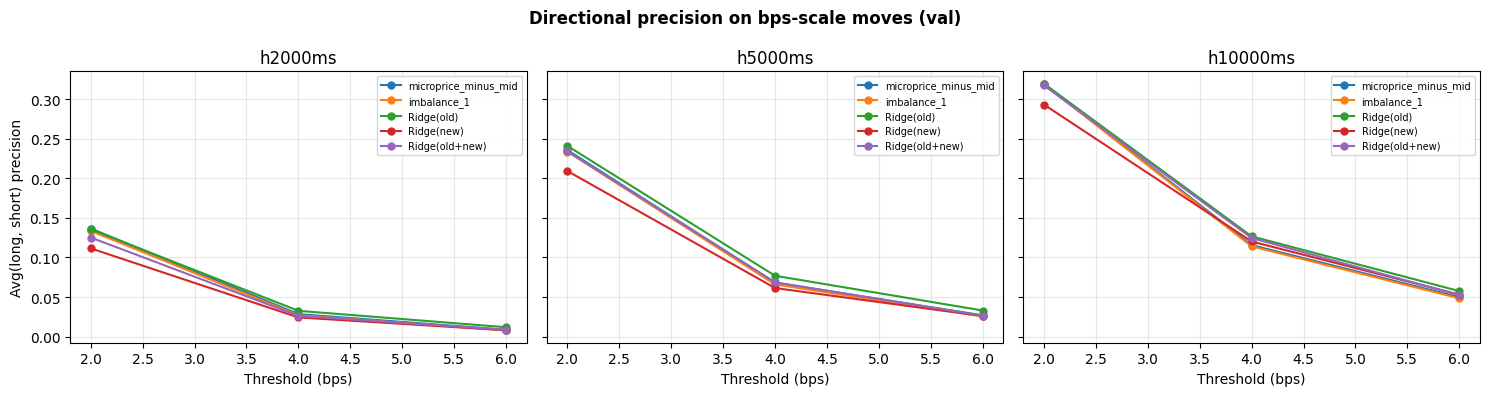

In [10]:
if n_h > 0:
    fig, axes = plt.subplots(1, n_h, figsize=(5 * n_h, 4), sharey=True, squeeze=False)
    axes = axes[0]
    for ax, h_ms in zip(axes, available_horizons):
        sub = val_df[val_df["horizon"] == h_ms]
        for model_name in sub["model"].unique():
            m_sub = sub[sub["model"] == model_name]
            avg_prec = (m_sub["long_precision"] + m_sub["short_precision"]) / 2
            ax.plot(m_sub["threshold_bps"], avg_prec, "o-", label=model_name, markersize=5)
        ax.set_xlabel("Threshold (bps)")
        ax.set_title(f"h{h_ms}ms")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
    axes[0].set_ylabel("Avg(long, short) precision")
    fig.suptitle("Directional precision on bps-scale moves (val)", fontweight="bold")
    fig.tight_layout()
    plt.show()

### Net-edge heatmap (val, fee sweep)

Rows — model; columns — horizon; values — `mean_signed_move_bps − fee`.
Separate panel per fee assumption.

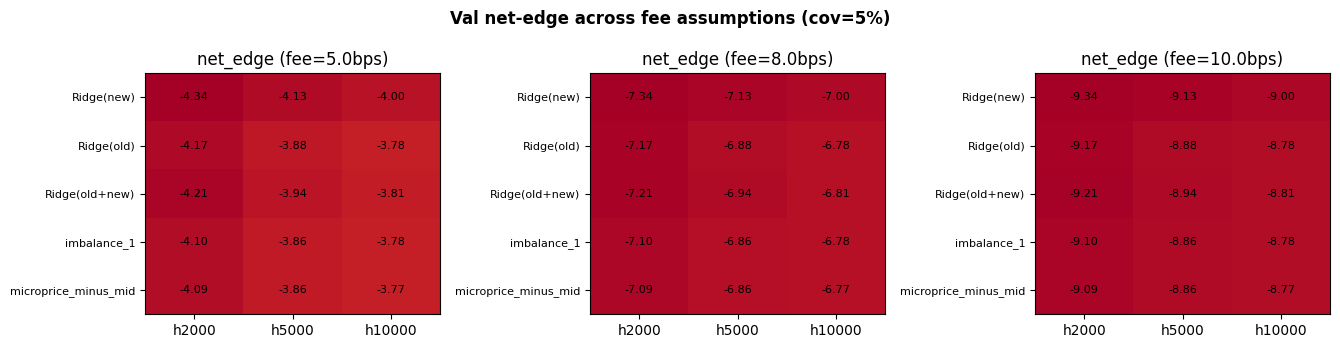

In [11]:
def net_edge_table(fee_bps: float) -> pd.DataFrame:
    sub = val_df[val_df["threshold_bps"] == THRESHOLDS_BPS[0]]  # not threshold-dependent
    pivot = sub.pivot_table(index="model", columns="horizon",
                             values="mean_signed_bps")
    return pivot - fee_bps

if n_h > 0:
    fig, axes = plt.subplots(1, len(FEE_SWEEP_BPS), figsize=(4.5 * len(FEE_SWEEP_BPS), 3.5), squeeze=False)
    axes = axes[0]
    for ax, fee in zip(axes, FEE_SWEEP_BPS):
        tbl = net_edge_table(fee)
        vmax = max(abs(tbl.min().min()), abs(tbl.max().max()))
        im = ax.imshow(tbl.values, aspect="auto", cmap="RdYlGn", vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(len(tbl.columns)))
        ax.set_xticklabels([f"h{c}" for c in tbl.columns])
        ax.set_yticks(range(len(tbl.index)))
        ax.set_yticklabels(tbl.index, fontsize=8)
        ax.set_title(f"net_edge (fee={fee}bps)")
        for i in range(tbl.shape[0]):
            for j in range(tbl.shape[1]):
                v = tbl.values[i, j]
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                         color="black", fontsize=8)
    fig.suptitle(f"Val net-edge across fee assumptions (cov={TARGET_COVERAGE:.0%})",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

## Best candidate → test

In [12]:
def best_candidate_per_horizon(val_df: pd.DataFrame) -> pd.DataFrame:
    sub = val_df[val_df["threshold_bps"] == THRESHOLDS_BPS[0]].copy()
    idx = sub.groupby("horizon")["mean_signed_bps"].idxmax()
    return sub.loc[idx].sort_values("horizon").reset_index(drop=True)

best_val = best_candidate_per_horizon(val_df)
print("Best val model per horizon (by mean_signed_bps):")
display(best_val[["horizon", "model", "coverage", "mean_signed_bps", "net_edge_default"]])

# Evaluate on test — reuse the fitted models and train-derived score_thr.
test_rows = []
for _, row in best_val.iterrows():
    h_ms = int(row["horizon"])
    model = trained_models[(h_ms, row["model"])]
    parts = data[h_ms]["parts"]
    train_score = model.predict(parts["train"])
    score_thr = score_threshold_for_coverage(np.abs(train_score), TARGET_COVERAGE)
    test_score = model.predict(parts["test"])
    test_label = parts["test"][LABEL_COL].values
    test_label_bps = label_to_bps(test_label)
    trade_mask = np.abs(test_score) > score_thr
    pred_sign = np.sign(test_score)
    long_mask = trade_mask & (pred_sign > 0)
    short_mask = trade_mask & (pred_sign < 0)
    signed_edge_bps = np.where(long_mask, test_label_bps,
                      np.where(short_mask, -test_label_bps, 0.0))
    mean_signed = float(signed_edge_bps[trade_mask].mean()) if trade_mask.any() else np.nan
    row_out = {
        "horizon": h_ms,
        "model": row["model"],
        "coverage": float(trade_mask.mean()),
        "long_n": int(long_mask.sum()),
        "short_n": int(short_mask.sum()),
        "mean_signed_bps": mean_signed,
    }
    for fee in FEE_SWEEP_BPS:
        row_out[f"net_edge_fee{int(fee)}"] = mean_signed - fee if not np.isnan(mean_signed) else np.nan
    test_rows.append(row_out)

test_df = pd.DataFrame(test_rows)
print("\nBest candidate on test:")
display(test_df)

Best val model per horizon (by mean_signed_bps):


,horizon,model,coverage,mean_signed_bps,net_edge_default
0,2000,microprice_minus_mid,0.0350,0.9057,-7.0943
1,5000,microprice_minus_mid,0.0350,1.1448,-6.8552
2,10000,microprice_minus_mid,0.0350,1.2304,-6.7696



Best candidate on test:


,horizon,model,coverage,long_n,short_n,mean_signed_bps,net_edge_fee5,net_edge_fee8,net_edge_fee10
0,2000,microprice_minus_mid,0.0386,15189,18129,0.7873,-4.2127,-7.2127,-9.2127
1,5000,microprice_minus_mid,0.0386,15189,18128,1.0303,-3.9697,-6.9697,-8.9697
2,10000,microprice_minus_mid,0.0386,15188,18127,1.1674,-3.8326,-6.8326,-8.8326


## Verdict

Automated qualitative summary based on test results.

- **Progress threshold**: mean signed move ≥ 6 bps with coverage ≥ 2 %.
- **Mixed**: 4–6 bps — direction right, but fee-margin thin on futures taker.
- **Not close**: < 4 bps — setup still far from taker viability.

In [13]:
def classify(mean_bps: float, cov: float) -> str:
    if np.isnan(mean_bps):
        return "n/a"
    if mean_bps >= 6.0 and cov >= 0.02:
        return "encouraging"
    if mean_bps >= 4.0:
        return "mixed"
    return "not close"


print("=" * 60)
print("VERDICT — test")
print("=" * 60)

if len(test_df) == 0:
    print("No test results.")
else:
    best_row = test_df.loc[test_df["mean_signed_bps"].idxmax()]
    ridge_full_rows = val_df[(val_df["model"] == "Ridge(old+new)") &
                              (val_df["threshold_bps"] == THRESHOLDS_BPS[0])]
    ridge_old_rows = val_df[(val_df["model"] == "Ridge(old)") &
                             (val_df["threshold_bps"] == THRESHOLDS_BPS[0])]
    if len(ridge_full_rows) and len(ridge_old_rows):
        delta_bps = (ridge_full_rows.set_index("horizon")["mean_signed_bps"]
                      - ridge_old_rows.set_index("horizon")["mean_signed_bps"])
        new_helps = (delta_bps > 0.2).any()
    else:
        new_helps = False

    print(f"Most promising horizon:          h{int(best_row['horizon'])}ms")
    print(f"Best simple model/signal:        {best_row['model']}")
    print(f"Test mean signed move:           {best_row['mean_signed_bps']:.3f} bps")
    print(f"Test coverage:                   {best_row['coverage']:.2%}")
    for fee in FEE_SWEEP_BPS:
        net = best_row[f"net_edge_fee{int(fee)}"]
        print(f"Net edge @ fee={fee:.0f}bps:              {net:.3f} bps")
    print(f"New features help materially:    {'yes' if new_helps else 'no/mixed'}")
    print(f"Taker-viability status:          {classify(best_row['mean_signed_bps'], best_row['coverage'])}")

VERDICT — test
Most promising horizon:          h10000ms
Best simple model/signal:        microprice_minus_mid
Test mean signed move:           1.167 bps
Test coverage:                   3.86%
Net edge @ fee=5bps:              -3.833 bps
Net edge @ fee=8bps:              -6.833 bps
Net edge @ fee=10bps:              -8.833 bps
New features help materially:    no/mixed
Taker-viability status:          not close
